In [83]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Files/folders/key parameters

In [3]:
dir_data = Path("./data")
f_p = dir_data / 'MS00103_v8_P.csv'
f_ta = dir_data / 'MS00101_v9_Ta.csv'
f_rh = dir_data / 'MS00102_v9_RH.csv'
f_vpd = dir_data / 'MS00108_v9_VPD.csv'
f_q = dir_data / 'Discharge_daily_1979_2022.csv'


In [21]:
site = 'PRIMET'

# Read the raw data

In [26]:
def get_met_data(f, site=site):
    df = pd.read_csv(f)
    df = df[df.SITECODE == site]
    df.index = pd.to_datetime(df.DATE)
    return df.sort_index()


<Axes: xlabel='Date'>

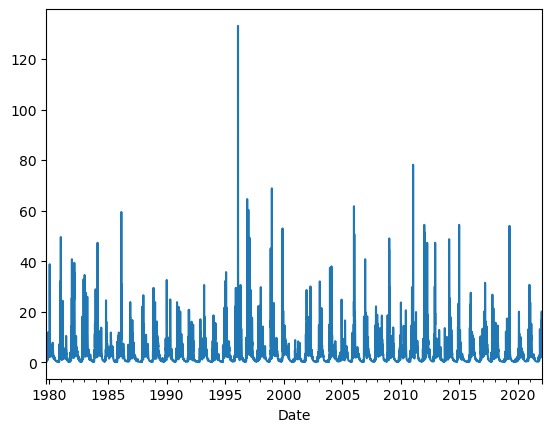

In [64]:
# Discharge
df_q = pd.read_csv(f_q, index_col=0)
df_q.index = pd.to_datetime(df_q.index)
df_q = df_q['LOOKOUT']

df_q.plot()

<Axes: xlabel='DATE'>

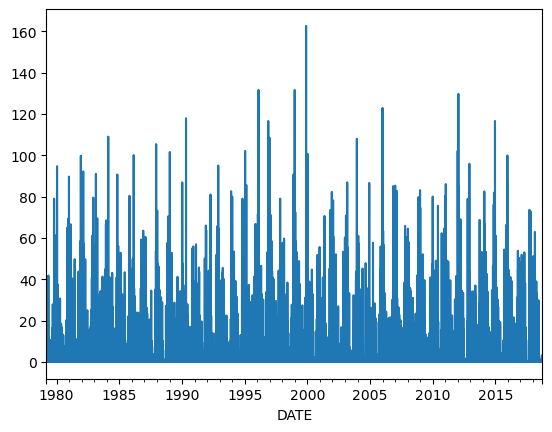

In [63]:
# Precipitation
df_p = get_met_data(f_p)
df_p = df_p['PRECIP_TOT_DAY']
df_p.plot()


<Axes: xlabel='DATE'>

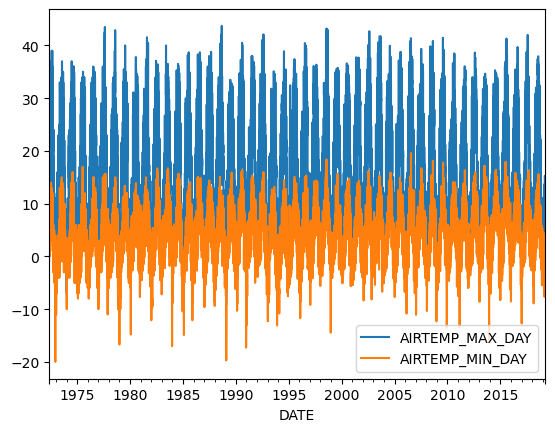

In [62]:
# Air temperature
df_ta = get_met_data(f_ta)
df_ta = df_ta[['AIRTEMP_MAX_DAY','AIRTEMP_MIN_DAY']][df_ta.HEIGHT==150].groupby('DATE').mean()
df_ta.plot()


<Axes: xlabel='DATE'>

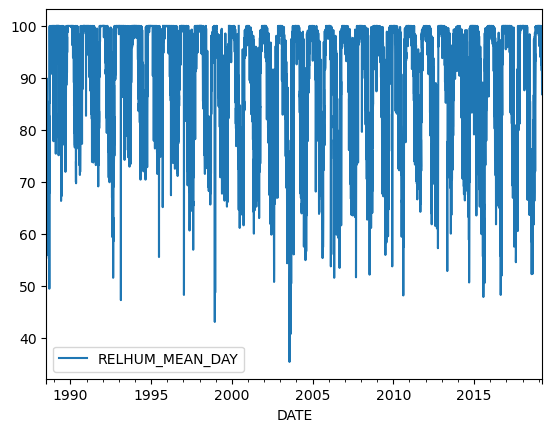

In [72]:
# Relative humidity
df_rh = get_met_data(f_rh)
df_rh = df_rh[['RELHUM_MEAN_DAY']][df_rh.HEIGHT==150].groupby('DATE').mean()
df_rh.plot()

In [35]:
# # Vapor pressure deficit
# df_vpd = get_met_data(f_vpd)
# df_vpd[['VPD_MEAN_DAY']].plot()

# Concatnate the data

In [94]:
start, end = '1979-10-01', '2017-09-30'
new_names = ['Q', 'P', 'TAMAX', 'TAMIN']

In [101]:
df_concat = pd.concat([df_q, df_p, df_ta], axis=1)
df_concat = df_concat.rename(columns=dict(zip(df_concat.keys().to_list(), new_names)))
df_concat = df_concat[start:end]
df_concat.interpolate(inplace=True)

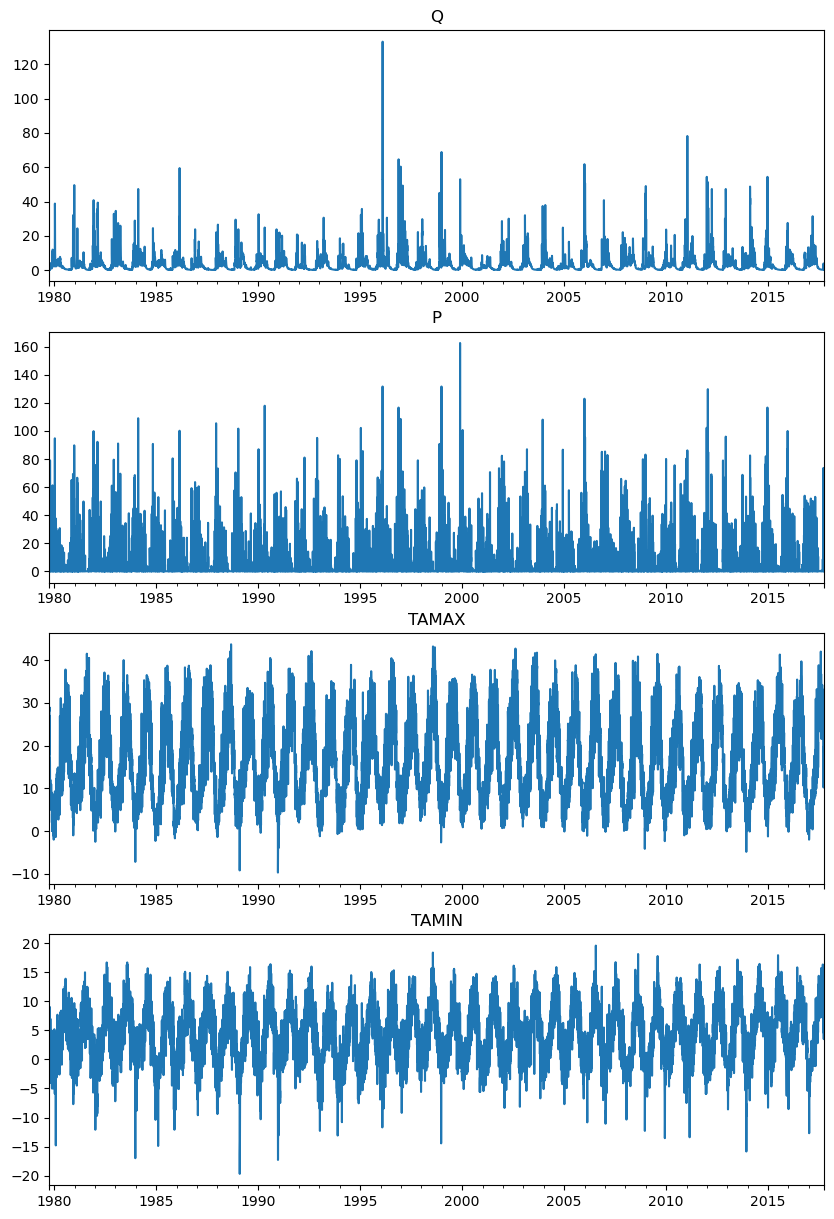

In [102]:
fig, axes = plt.subplots(4, 1, figsize=(10,15))
for i,ax in enumerate(axes):
    varn = new_names[i]
    df_concat[varn].plot(ax=ax)
    ax.set(title=varn)

In [103]:
# Save the preprocessed data
df_concat.to_csv(dir_data / 'preprocessed.csv')
